# AfyaFlow

### Hospital-Wide Outpatient Demand & Resource Allocation Prototype

### AIC Kijabe Hospital
AIC Kijabe Hospital is located in Kijabe, Kiambu County, Kenya, started as Kijabe Station was first established by missionaries from AIM as an outpost in 1903 upgrading first hospital at Kijabe, Theodora Hospital, was established in 1915. This served the medical needs of the area until the present complex was begun.
Today, Kijabe Hospital is a non-profit, 363-bed hospital owned and operated by AIC of Kenya as part of a network of four hospitals and 45 dispensaries. It has 1,078 employees as of Jul 26 and strives to balance Kenyan and missionary consultants. The hospital has daily average visits of about 355 and monthly average vistis of 10,677 patients a broad range of inpatient and outpatient curative services to people from the surrounding farming communities.

### Project Overview

The model uses historical outpatient records to identify patterns in patient attendance and predict periods of high demand across hospital departments. These insights will support  staff in providing medical services and efficient resource allocation, helping the hospital reduce congestion and improve patient flow.


# Business Understanding

### Problem Definition

Kijabe experiences variation in patient volumes across days and departments, making it difficult to anticipate where demand will occur and whether available capacity will be sufficient. During high-demand periods, patient volumes may exceed the available clinical capacity, contributing to congestion, longer waiting times and increased pressure on staff and resources. For instance patient volumes vary by day where weekdays have higher visits than weekends with with an average of 35 - 69 vists per hour during peak working hours potentially contribution to longer wait times for patients

### Business Objectives

AfyaFlow aims to use Kijabe Hospital's historical outpatient data and relevant internal operational factors to understand and predict patient demand across the hospital. The goal is to identify where and when high patient volumes are likely to occur and provide insights that can support proactive planning and decision-making.

The project aims:
- To predict outpatient demand in the hospital and time periods.
- To identify departments, days, and time periods that are most likely to experience high patient volumes and congestion.
- To analyse historical patterns and factors that influence changes in outpatient demand.
- To support decisions on how available clinicians and resources can be allocated based on predicted demand.
- To provide hospital-wide insights to support capacity planning and improve patient flow.

### Research Questions
* How can historical patient data and predictive analytics be used to anticipate patient demand and support capacity planning to reduce congestion at Kijabe Hospital?
* What temporal patterns influence patient demand at Kijabe Hospital?
* Can patient-level historical patterns identify recurring patients and help explain predictable components of hospital demand?
* Can a scenario-based simulation help hospital decision-makers evaluate the potential effect of resource allocation decisions on congestion?
  
### Key Stakeholders

* Hospital Management: Requires hospital-wide demand insights to support capacity, staffing, and resource planning.
* Department Managers: Need demand forecasts to prepare for expected changes in patient volumes.
* Clinicians and Nurses: Benefit from better planning and distribution of workload and available clinical capacity.
* Patients: Benefit from improved patient flow, reduced waiting times, and more efficient service delivery.

### Data Science Tasks

The project will analyse Kijabe Hospital's historical outpatient data to identify patterns in patient attendance across departments and different time periods. Predictive models will then be developed to forecast future outpatient demand and identify periods of potentially high patient volumes. These predictions will be translated into decision-support insights to help the hospital plan staffing and resources according to anticipated demand.

# Data Understanding

### Data Overview

Opd_data.xlsx comes from Kijabe Hospital's outpatient records system. It has 306,306 rows and 6 columns, covering 1 June 2024 to 19 August 2026 (about 26.5 months, with the last month not fully complete). This is the only data we have for the project so far there's no separate data on staff numbers or bed availability yet.

#### Column Description
* PatientNumber - Represents the unique hospital identifier assigned to each patient. It is used to link repeat visits to the same individual and is not a row identifier, since one patient can appear many times.
* RegistrationDate - Represents the date and time at which the patient was registered into a service queue. This is the main temporal field in the dataset and provides the year, month, day of week and hour used for demand analysis.
* Gender - Represents the gender of the patient, recorded as Male or Female.
* Age - Represents the age of the patient at the time of registration, recorded as text with a unit attached, for example "38 Yr(s)", "6 Mth(s)", "3 Week(s)" or "5 Days(s)".
* QueuedTo - Represents the department or clinic the patient was queued to, for example General OPD, MCH, Chronic Care Clinic, Oncology, Renal or Dental. This is the main department field and the unit at which demand is analysed.
* ConsultDescription - Represents the type or purpose of the consultation the patient was booked for, for example General Outpatient Care, Admission, Chemotherapy, MCH Clinic or ENT Return Visit. It gives a finer-
grained view of service type within a department, and also distinguishes new visits from return visits.


In [ ]:
# Library Imports
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from datetime import time


#Load Dataset
data =  pd.read_csv("Opd_data,v2.csv")

In [ ]:
#basic understanding of the datset
print(f'The dataset has {data.shape[0]} rows and {data.shape[1]} columns\n')
print('Dataset Columns:\n',data.columns)
print('\n Dataset Data types:\n',data.dtypes)

The dataset has 306306 rows and 6 columns

Dataset Columns:
 Index(['PatientNumber', 'RegistrationDate', 'Gender', 'Age', 'QueuedTo',
       'ConsultDescription'],
      dtype='object')

 Dataset Data types:
 PatientNumber         object
RegistrationDate      object
Gender                object
Age                   object
QueuedTo              object
ConsultDescription    object
dtype: object


Observation: The dataset has 6 columns. All the data types are correct apart fromthe age columns that should be numeric

In [ ]:
#Checking Info of the data
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 306306 entries, 0 to 306305
Data columns (total 6 columns):
 #   Column              Non-Null Count   Dtype 
---  ------              --------------   ----- 
 0   PatientNumber       306306 non-null  object
 1   RegistrationDate    306306 non-null  object
 2   Gender              306291 non-null  object
 3   Age                 305735 non-null  object
 4   QueuedTo            299528 non-null  object
 5   ConsultDescription  299920 non-null  object
dtypes: object(6)
memory usage: 14.0+ MB


In [ ]:
#checking statistics
data.describe(include='O')

,PatientNumber,RegistrationDate,Gender,Age,QueuedTo,ConsultDescription
count,306306,306306,306291,305735,299528,299920
unique,80928,202637,4,142,44,79
top,010099285,04-Feb-2025 00:00,Female,2 Yr(s),GENERAL OPD,General Outpatient Care
freq,266,45,142251,7464,85959,49377


In [ ]:
#Checking dataset uniformity
data.head()

,PatientNumber,RegistrationDate,Gender,Age,QueuedTo,ConsultDescription
0,010575758,01-Jun-2024 00:00,Male,38 Yr(s),GENERAL OPD,GEneral Outpatient Care( NEW )
1,010575713,01-Jun-2024 00:00,Female,29 Yr(s),NaN,NaN
2,010569291,01-Jun-2024 00:04,Female,44 Yr(s),GENERAL OPD,General Outpatient Care
3,010575732,01-Jun-2024 00:04,Female,78 Yr(s),GENERAL OPD,General Outpatient Care
4,010575731,01-Jun-2024 00:10,Female,2 Yr(s),ADMISSION,Admission


In [ ]:
data.tail()

,PatientNumber,RegistrationDate,Gender,Age,QueuedTo,ConsultDescription
306301,010625187,19-Aug-2026 11:39,Male,3 Mth(s),DAYCASE,DAYCASE
306302,010631396,19-Aug-2026 11:40,Female,1 Week(s),MCH,Child Welfare and Immunization (CWC)
306303,010632308,19-Aug-2026 11:41,Male,45 Yr(s),GENERAL OPD,GEneral Outpatient Care( NEW )
306304,010592441,19-Aug-2026 11:41,Male,18 Mth(s),PAEDS BKKH,Pediatrics
306305,010621962,19-Aug-2026 11:41,Female,30 Yr(s),MCH,MCH Clinic


In [ ]:
data.sample(5)

,PatientNumber,RegistrationDate,Gender,Age,QueuedTo,ConsultDescription
64412,04022941,02-Dec-2024 09:37,Female,33 Yr(s),MCH,MCH Clinic
96554,010581271,05-Mar-2025 07:19,Female,39 Yr(s),SPECIALITY CLINIC,ORTHOPEDIC
243474,010616101,19-Mar-2026 07:47,Female,64 Yr(s),CHRONIC CARE CLINIC (DM/HTN/TB/CCC),Diabetic clinic
136551,03014484,19-Jun-2025 00:00,Male,39 Yr(s),ADMISSION,Admission
294323,010629898,23-Jul-2026 00:00,Female,41 Yr(s),ADMISSION,Admission


Observation: The data is uniform, however the gender column and consultdescription has a mix of uppercase and lowercase letters

In [ ]:
print(data['QueuedTo'].unique())

['GENERAL OPD ' nan 'ADMISSION' 'CASUALTY' 'Gen Surg OPD' 'RENAL' 'MCH'
 'PHYSIOTHERAPY' 'DAYCASE' 'DENTAL' 'SPECIALITY CLINIC' 'PSYCHOLOGY'
 'OHNS' 'ONCOLOGY' 'PRIVATE CLINIC' 'EYE CLINIC' 'PAEDS BKKH'
 'CHRONIC CARE CLINIC (DM/HTN/TB/CCC)' 'Ortho OPD' 'PALLIATIVE'
 'Audiology' 'NUTRITION' 'OCCUPATIONAL THERAPY'
 'NEURO SURGERY CONSULTATION' 'FAMILY MEDICINE' 'DIABETIC CLINIC'
 'FAMILY CLINIC' 'Gynae OPD' 'MATERNITY NURSERY' 'TELEMEDICINE' 'MORGUE'
 'CARDIOLOGY' 'KJ000104/19' 'PAEDS' 'RESPIRATORY CENTER' 'HTS' 'PATHOLOGY'
 'MENTAL HEALTH' 'Naivasha Town Clinic' 'MEB SPECIALITY CLINIC'
 'NEUROSURGERY' 'PEDIATRIC NEUROLOGY' 'MEB PHYSIOTHERAPY' 'ANAESTHESIA'
 'All']


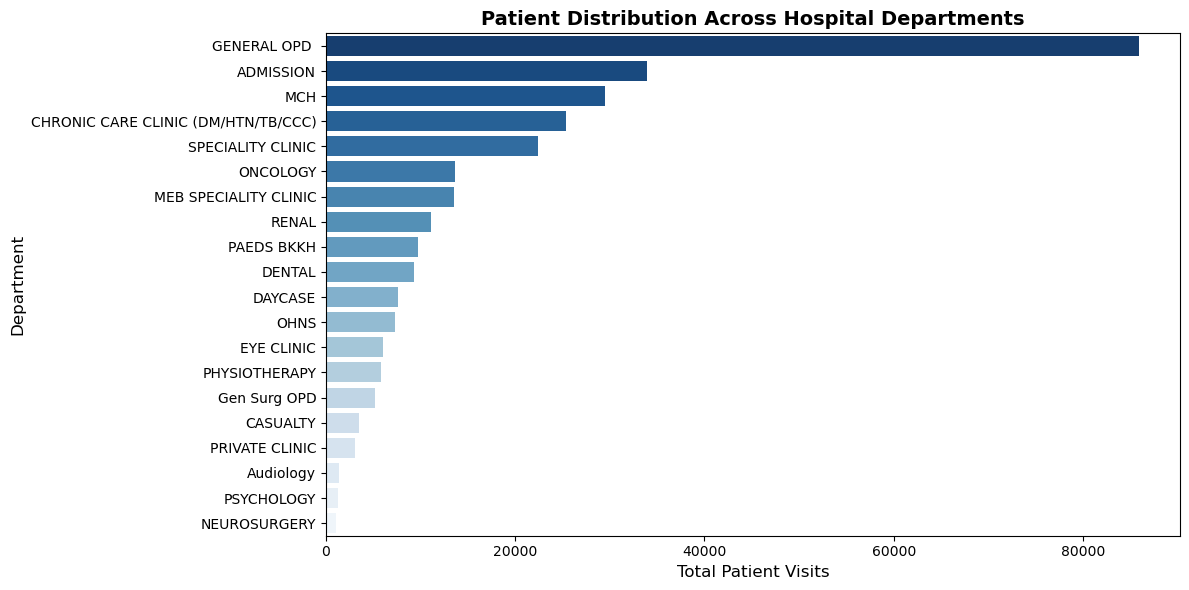

In [ ]:
plt.figure(figsize=(12, 6))

# visits per department and sort descending for top 20
dept_counts = data["QueuedTo"].value_counts().head(20)

# horizontal bar plot
sns.barplot(x=dept_counts.values, y=dept_counts.index, palette="Blues_r")

plt.title("Patient Distribution Across Hospital Departments", fontsize=14, fontweight="bold")
plt.xlabel("Total Patient Visits", fontsize=12)
plt.ylabel("Department", fontsize=12)
plt.tight_layout()
plt.show()

In [ ]:
print(data['ConsultDescription'].unique())

['GEneral Outpatient Care( NEW )' nan 'General Outpatient Care'
 'Admission' 'EMERGENCY' 'CONSULT' 'RENAL DIALYSIS'
 'Child Welfare and Immunization (CWC)' 'MCH Clinic' 'Physiotherapy'
 'MCH (New Patient)' 'DAYCASE' 'Dental Care' 'ORTHOPEDIC' 'UROLOGY'
 'COUNSELLING PSYCHOLOGY' 'ENT First Visit' 'Chemotherapy'
 'GENERAL SURGERY' 'Ophthalmology.' 'ENT Return Visit' 'Pediatrics '
 'Comprehensive Care Centre (CCC)' 'Developmental Clinic '
 'Palliative Revisit' 'Diabetic clinic' 'Staff Clinic' 'ECHO'
 'Gen Surg OPD' 'PLASTICS' 'Cardiology' 'ONCOLOGY CONSULTATION' 'RVA'
 'GYNAECOLOGY' 'Nutrition Consult' 'OCCUPATIONAL THERAPY'
 'SPECIALITY IMED' 'BREAST' 'ANC Revisit' 'Family Planning'
 'Consultant Clinic' 'Paediatric Psychiatry' 'Psychiatry'
 'RENAL CONSULTATION' 'Oncology Service' 'Revisit' 'Counselling'
 'Hepatitis b vaccine' 'PEADS SURGE' 'Clinical psychology consultation'
 'TB CLINIC' 'Postnatal (PNC)' 'HAND CLINIC' 'HYPERTENSION CLINIC'
 'Gyn-oncology' 'Surgical OPD' 'TELEMEDICINE' 'E

In [ ]:
#checking for missing values
data.isna().sum()

PatientNumber            0
RegistrationDate         0
Gender                  15
Age                    571
QueuedTo              6778
ConsultDescription    6386
dtype: int64

In [ ]:
missing = data.isnull().sum()
missing_percent = (missing/len(data)) * 100
pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_percent
})

,Missing Count,Missing %
PatientNumber,0,0.000000
RegistrationDate,0,0.000000
Gender,15,0.004897
Age,571,0.186415
QueuedTo,6778,2.212820
ConsultDescription,6386,2.084843


Observation: There are missing values, however they make up a small percentage of the whole data so dropping them will not cause us to lose important insights of the data

In [ ]:
#checking for duplicated values
data.duplicated().sum()

355

Observation: We will drop these duplicate values so that we ensure our model learns actual patterns and not repetative ones

In [ ]:
#checking how many patients have visited hospital
print(data['PatientNumber'].nunique())
print(len(data))

80928
306306


observation: 80928 patients visited the hospital and the length of the data being larger indicated that there has been patients who have returned to the hospital

In [ ]:
# example of return patients
visits = data['PatientNumber'].value_counts()
visits.head()

PatientNumber
010099285    266
010543010    252
010527584    249
010112639    248
010315077    247
Name: count, dtype: int64

In [ ]:
# Minimum and maximum dates
dates = pd.to_datetime(data['RegistrationDate'], errors='coerce')
print(f'min: {dates.min()}')
print(f'max: {dates.max()}')

# Time destribution
dates.dt.hour.value_counts().sort_index()

min: 2024-06-01 00:00:00
max: 2026-08-19 11:41:00


RegistrationDate
0     19822
1      1679
2      1042
3       958
4      1627
5      4440
6      9234
7     25072
8     55567
9     51437
10    35298
11    28744
12    20167
13    12188
14    10107
15     8478
16     6645
17     3638
18     2567
19     2085
20     1771
21     1543
22     1245
23      952
Name: count, dtype: int64

Text(0, 0.5, 'Number of patients')

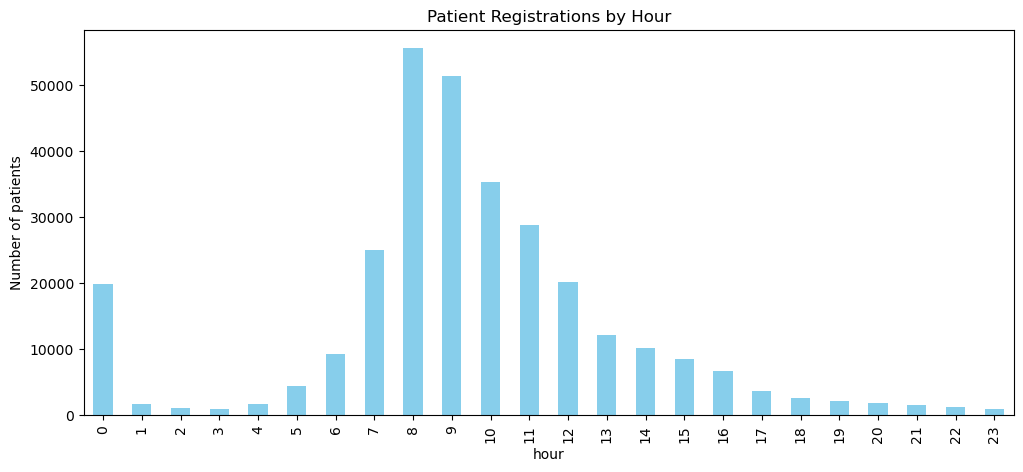

In [ ]:
#visual
data["temp_datetime"] = dates
data["hour"] = dates.dt.hour

data["hour"].value_counts().sort_index().plot(
    kind="bar",
    figsize=(12,5),
    title="Patient Registrations by Hour",
    color='skyblue')
plt.ylabel('Number of patients')

Observation: The busiest hours of the day are usually within 07:00 and 14:00 having the high number of patients. From the time range 08:00 and 09:00 are the busiest

In [ ]:
# daily visits
data['temp_datetime'].dt.day_name().value_counts()

temp_datetime
Monday       60299
Tuesday      59702
Thursday     59142
Wednesday    55624
Friday       52464
Saturday     11339
Sunday        7736
Name: count, dtype: int64

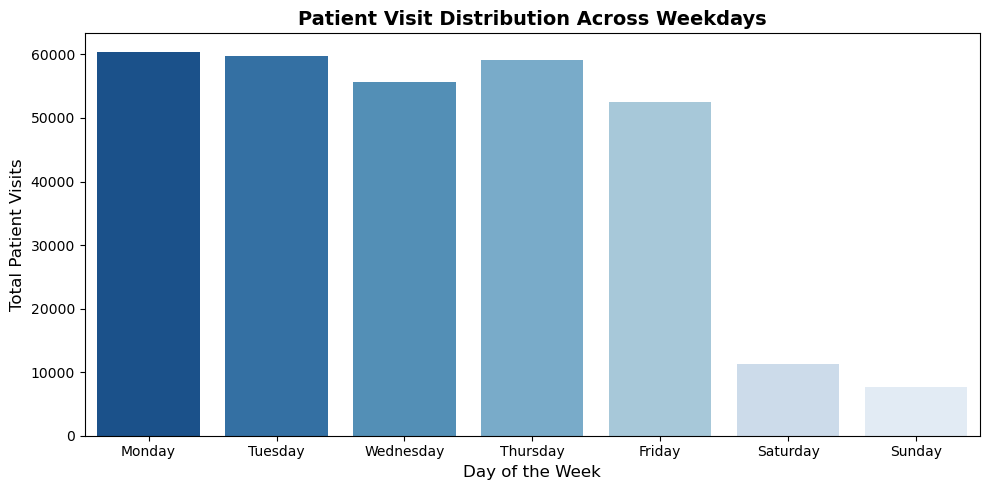

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
data["RegistrationDate"] = pd.to_datetime(data["RegistrationDate"], errors="coerce")
data["day_of_week"] = data["RegistrationDate"].dt.day_name()

# Define chronological weekday order
weekday_order = [
    "Monday", "Tuesday", "Wednesday", "Thursday",
    "Friday", "Saturday", "Sunday"
]

# Count visits per weekday and reindex
weekday_counts = data["day_of_week"].value_counts().reindex(weekday_order)

# Plot distribution
plt.figure(figsize=(10, 5))
sns.barplot(x=weekday_counts.index, y=weekday_counts.values, palette="Blues_r")
plt.title("Patient Visit Distribution Across Weekdays", fontsize=14, fontweight="bold")
plt.xlabel("Day of the Week", fontsize=12)
plt.ylabel("Total Patient Visits", fontsize=12)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

Mid-Week Surge

Patient volume concentrates heavily during mid-week windows (typically Tuesday through Thursday), driven by scheduled outpatient clinics, specialist availability, and elective check-ins.

Weekend Drop-off

Volumes decline sharply over the weekend, reflecting reduced ambulatory service hours and limited elective scheduling, which leaves emergency and inpatient units handling the baseline load.

In [ ]:
#Number of departmnets and how many visits
print(f'Number of departments:', data["QueuedTo"].nunique())
data['QueuedTo'].value_counts(dropna=False)

Number of departments: 44


QueuedTo
GENERAL OPD                            85959
ADMISSION                              33880
MCH                                    29467
CHRONIC CARE CLINIC (DM/HTN/TB/CCC)    25366
SPECIALITY CLINIC                      22356
ONCOLOGY                               13606
MEB SPECIALITY CLINIC                  13523
RENAL                                  11103
PAEDS BKKH                              9734
DENTAL                                  9252
DAYCASE                                 7596
OHNS                                    7290
NaN                                     6778
EYE CLINIC                              6027
PHYSIOTHERAPY                           5826
Gen Surg OPD                            5156
CASUALTY                                3460
PRIVATE CLINIC                          3075
Audiology                               1379
PSYCHOLOGY                              1223
NEUROSURGERY                            1032
OCCUPATIONAL THERAPY                     815
N

In [ ]:
# Visits per consultation type
data["ConsultDescription"].value_counts(dropna=False)

ConsultDescription
General Outpatient Care           49377
Admission                         33886
CONSULT                           33336
GEneral Outpatient Care( NEW )    21398
MCH Clinic                        19465
                                  ...  
PAIN CLINIC                           2
Head & Neck Return Visit              1
Staff Wellness Package                1
HEAD AND NECK VISIT                   1
Private Gyn Oncology                  1
Name: count, Length: 80, dtype: int64

Observation: Majority visits are:
- General Outpatient Care           
- Admission                         
- CONSULT

In [ ]:
#Distribution of gender
data["Gender"].value_counts(dropna=False)


Gender
Female    142251
Male      112802
FEMALE     32185
MALE       19053
NaN           15
Name: count, dtype: int64

Observation: Theres inconsistent formating which needs to be cleaned

In [ ]:
#Age distribution
data["Age"].value_counts()

Age
2 Yr(s)      7464
31 Yr(s)     5741
30 Yr(s)     5533
29 Yr(s)     5418
33 Yr(s)     5255
             ... 
2 Days(s)       2
117 Yr(s)       1
107 Yr(s)       1
3 Days(s)       1
121 Yr(s)       1
Name: count, Length: 142, dtype: int64

Observation

1. Data description
- What's in it: Patient ID, registration date/time, gender, age (written as text, like "38 Yr(s)"), which department the patient was sent to (44 possible departments), and the type of visit (79 possible types). Everything is text or dates no ready-made numbers or categories yet.
- Who the patients are: 80,928 different patients, visiting 3.8 times on average. About 57% are female, 43% male. Median age is 40. Most patients only come once (39%), but a small group (7.7%) comes 10+ times, likely people with ongoing conditions needing regular care.
- Departments: 7 out of 44 departments make up about 70% of all visits, General Outpatient, Admission, MCH, Chronic Care, Speciality Clinic, Oncology, and Renal. The rest get far fewer visits.
- Patterns over time: More patients come on weekdays than weekends, with Monday the busiest and weekends much quieter. Most patients arrive between 8-9am, then it tapers off through the day. The number of visits per month stays fairly steady (10,000–13,000), though the last month isn't fully counted yet.

2. Verify Data Quality

These are common problems in hospital records like this none of them are serious enough to stop the project, but they all need fixing before we build any models:

- Missing information: some rows are missing gender (15), age (571), department (6,778), or visit type (6,386). The missing department and visit type are the most important to fix, since they're central to what we're trying to study.
- 355 rows are exact copies of another row — probably accidental double entries.
- Gender is written inconsistently — sometimes "Male", sometimes "MALE".
- Visit types are written inconsistently too, with typos and different spellings for what should be the same thing (e.g. "General Outpatient Care" vs "GEneral Outpatient Care( NEW )"). We'll need to fix the typos but keep any real differences, like whether it's a new or returning patient.
- Age is written as text, not numbers, and mixes different units (years, months, weeks, days), so it needs to be converted before we can use it.
- A few ages are unrealistic (over 110 years old) — most likely mistakes.
- 3 rows list departments that don't make sense — they look like test entries, not real departments.
- 10,292 rows show an exact midnight timestamp, which is probably just a placeholder for "we don't know the exact time" rather than real midnight visits — so we should be careful using time-of-day data for these.

# Data Cleaning

### Missing Values

In [ ]:
# missing dependable columns queuedto & consultdescription
missing_counts = data[["QueuedTo", "ConsultDescription"]].isna().sum()
print(print(missing_counts))

QueuedTo              6778
ConsultDescription    6386
dtype: int64
None


In [ ]:
# boolean to check for rows where both are null
both_missing = data["QueuedTo"].isna() & data["ConsultDescription"].isna()

print(f"Rows where both are missing: {both_missing.sum()}")

Rows where both are missing: 6386


In [ ]:
# A side by side comparison of both columns for rows where at least one is missing
missing_audit = data[data["QueuedTo"].isna() | data["ConsultDescription"].isna()]

missing_audit[["PatientNumber", "RegistrationDate", "QueuedTo", "ConsultDescription",]].sample(5)

,PatientNumber,RegistrationDate,QueuedTo,ConsultDescription
77053,020022456,2025-01-15,NaN,NaN
215992,010609594,2026-01-15,NaN,NaN
24312,010571792,2024-08-09,NaN,NaN
97531,010548493,2025-03-07,NaN,NaN
14523,020095356,2024-07-12,NaN,NaN


**Observation:**

Correlated missing values

The missing counts in 'QueuedTo' and 'ConsultDescription' columns are close in magnitude 6778 and 6386 missing values respectively suggesting that the missing values often occur as an unregistered patient encounters where routing metdata was never logged



In [ ]:
# drop rows where both queuedto and consultdescription are nan
df_cleaned = data.dropna(subset=["QueuedTo", "ConsultDescription"], inplace=True)

In [ ]:
missing_counts2 = data[["QueuedTo", "ConsultDescription"]].isna().sum()
print(print(missing_counts2))

QueuedTo              0
ConsultDescription    0
dtype: int64
None


### Duplicates

In [ ]:
data[data.duplicated(keep=False)].sort_values('PatientNumber').head()

,PatientNumber,RegistrationDate,Gender,Age,QueuedTo,ConsultDescription,temp_datetime,hour,day_of_week
172478,010607509,2025-09-19 17:03:00,Male,18 Yr(s),GENERAL OPD,GEneral Outpatient Care( NEW ),2025-09-19 17:03:00,17,Friday
172479,010607509,2025-09-19 17:03:00,Male,18 Yr(s),GENERAL OPD,GEneral Outpatient Care( NEW ),2025-09-19 17:03:00,17,Friday
172484,010607511,2025-09-19 17:47:00,Female,22 Yr(s),GENERAL OPD,GEneral Outpatient Care( NEW ),2025-09-19 17:47:00,17,Friday
172485,010607511,2025-09-19 17:47:00,Female,22 Yr(s),GENERAL OPD,GEneral Outpatient Care( NEW ),2025-09-19 17:47:00,17,Friday
172494,010607515,2025-09-19 21:22:00,Female,21 Yr(s),GENERAL OPD,GEneral Outpatient Care( NEW ),2025-09-19 21:22:00,21,Friday


**Observation**

Recorded variables i.e PatientNumber, RegistrationDate, Gender, Age, QueuedTo	ConsultDescription match identically between paired index rows confirming complete transactional duplication rather than clinical routing

In [ ]:
# total duplicates
data.duplicated().sum()

355

In [ ]:
# total unique duplicates
print(data.duplicated(subset=["PatientNumber", "RegistrationDate"]).sum())

366


In [ ]:
# drop duplicates
data = data.drop_duplicates()

data.duplicated().sum()

0

In [ ]:
dupes = data[data.duplicated(subset=["PatientNumber", "RegistrationDate"],keep=False)
            ].sort_values(["PatientNumber", "RegistrationDate"])

dupes

,PatientNumber,RegistrationDate,Gender,Age,QueuedTo,ConsultDescription,temp_datetime,hour,day_of_week
193239,010611177,2025-11-11 13:40:00,Female,54 Yr(s),GENERAL OPD,GEneral Outpatient Care( NEW ),2025-11-11 13:40:00,13,Tuesday
193240,010611177,2025-11-11 13:40:00,Female,54 Yr(s),ADMISSION,Admission,2025-11-11 13:40:00,13,Tuesday
201188,010612669,2025-12-01 15:09:00,Female,54 Yr(s),GENERAL OPD,CONSULT,2025-12-01 15:09:00,15,Monday
201189,010612669,2025-12-01 15:09:00,Female,54 Yr(s),GENERAL OPD,GEneral Outpatient Care( NEW ),2025-12-01 15:09:00,15,Monday
208810,010614068,2025-12-21 20:15:00,Female,68 Yr(s),GENERAL OPD,GEneral Outpatient Care( NEW ),2025-12-21 20:15:00,20,Sunday
208811,010614068,2025-12-21 20:15:00,Female,68 Yr(s),ADMISSION,Admission,2025-12-21 20:15:00,20,Sunday
245573,010621065,2026-03-24 20:39:00,Male,43 Yr(s),GENERAL OPD,GEneral Outpatient Care( NEW ),2026-03-24 20:39:00,20,Tuesday
245574,010621065,2026-03-24 20:39:00,Male,43 Yr(s),GENERAL OPD,CONSULT,2026-03-24 20:39:00,20,Tuesday
245923,010621132,2026-03-25 11:30:00,Male,54 Yr(s),GENERAL OPD,ENT First Visit,2026-03-25 11:30:00,11,Wednesday
245924,010621132,2026-03-25 11:30:00,Male,54 Yr(s),GENERAL OPD,GEneral Outpatient Care( NEW ),2026-03-25 11:30:00,11,Wednesday


In [ ]:
# drop unique duplicates
records = [193239, 201189, 208810, 245573, 282393, 300782, 296103, 296102, 296046, 279573,267040, 245923]

data = data.drop(records)

**Observation**

The cleaning specifically redundant (NEW) registration logging records such as patient 010611177 shown in indicies 193239 and 193240 implying the dropped rows are secondary
However the patients' comprehensive historical follow up visits were maintained

### Cleaning Timestamps

In [ ]:
# total number of midnight entries(00:00)
midnight = data[
    pd.to_datetime(data["RegistrationDate"]).dt.time ==
    pd.Timestamp("00:00").time()
]

print(len(midnight))

0


In [ ]:
midnight.head()

,PatientNumber,RegistrationDate,Gender,Age,QueuedTo,ConsultDescription,temp_datetime,hour,day_of_week


In [ ]:
# counts per department
midnight[["ConsultDescription", "QueuedTo"]].value_counts().head(20)

Series([], Name: count, dtype: int64)

**Observation**

The concentration of 00:00 timestamps that represent a significant volume of records strongly indicates an administrative fallback default where the exact administration times were'nt captured by the system.

These can be observed dominating Admission and  DAYCASE categories which dont reflect standard walk-ins.

In [ ]:
# exact midnigt records
data["RegistrationDate"] = pd.to_datetime(data["RegistrationDate"])

time = data["is_exact_midnight"] = (data["RegistrationDate"].dt.hour == 0) & (data["RegistrationDate"].dt.minute == 0) & (data["RegistrationDate"].dt.second == 0)

print(data["is_exact_midnight"].value_counts())

is_exact_midnight
False    288825
Name: count, dtype: int64


In [ ]:
data[~data["is_exact_midnight"]].head()

,PatientNumber,RegistrationDate,Gender,Age,QueuedTo,ConsultDescription,temp_datetime,hour,day_of_week,is_exact_midnight
2,010569291,2024-06-01 00:04:00,Female,44 Yr(s),GENERAL OPD,General Outpatient Care,2024-06-01 00:04:00,0,Saturday,False
3,010575732,2024-06-01 00:04:00,Female,78 Yr(s),GENERAL OPD,General Outpatient Care,2024-06-01 00:04:00,0,Saturday,False
4,010575731,2024-06-01 00:10:00,Female,2 Yr(s),ADMISSION,Admission,2024-06-01 00:10:00,0,Saturday,False
5,010454966,2024-06-01 01:22:00,FEMALE,31 Yr(s),GENERAL OPD,General Outpatient Care,2024-06-01 01:22:00,1,Saturday,False
6,010573369,2024-06-01 01:36:00,Female,84 Yr(s),GENERAL OPD,General Outpatient Care,2024-06-01 01:36:00,1,Saturday,False


In [ ]:
from datetime import time

# sort time to be retained
data["RegistrationDate"] = pd.to_datetime(data["RegistrationDate"], errors="coerce")

# time filter mask safely
start_time = time(0, 0, 0)
end_time = time(0, 59, 59)
mask = data["RegistrationDate"].dt.time.between(start_time, end_time)
late_night_patients = data[mask]

print(f"Total late night records: {len(late_night_patients)}")

Total late night records: 2921


In [ ]:
mapping = (data.dropna(subset=["QueuedTo", "ConsultDescription"]).groupby("ConsultDescription")["QueuedTo"].agg(lambda x: x.value_counts().index[0]))
mapping.sample(5)

ConsultDescription
Nutrition Consult                NUTRITION
Psychiatry                      PSYCHOLOGY
ENT First Visit                       OHNS
Oncology Service                  ONCOLOGY
Renal Clinic         MEB SPECIALITY CLINIC
Name: QueuedTo, dtype: object

In [ ]:
midnight_copy = data.copy()

In [ ]:
# index label positions where midnight occurs
data["RegistrationDate"] = pd.to_datetime(data["RegistrationDate"], errors="coerce")
data["is_exact_midnight"] = data["RegistrationDate"].dt.time == pd.to_datetime("00:00:00").time()

midnight_labels = data[data["is_exact_midnight"]].index

sample_labels = []
for label in midnight_labels[:5]:
    #  positional index of this label get surrounding rows by label
    pos = data.index.get_loc(label)
    start_pos = max(0, pos - 2)
    end_pos = min(len(data) - 1, pos + 2)
    sample_labels.extend(data.index[start_pos:end_pos + 1])

print(data.loc[list(set(sample_labels)), ["PatientNumber", "RegistrationDate", "QueuedTo"]])

Empty DataFrame
Columns: [PatientNumber, RegistrationDate, QueuedTo]
Index: []


In [ ]:
# drop the exact midnight records
data = data[~data["is_exact_midnight"]].copy()

In [ ]:
data[["PatientNumber", "RegistrationDate", "is_exact_midnight"]].head()

,PatientNumber,RegistrationDate,is_exact_midnight
2,010569291,2024-06-01 00:04:00,False
3,010575732,2024-06-01 00:04:00,False
4,010575731,2024-06-01 00:10:00,False
5,010454966,2024-06-01 01:22:00,False
6,010573369,2024-06-01 01:36:00,False


**Observation**

Dropping of the exact midnight records eliminates artificial spikes that dont reflect true patient flow dynamics, preserving legitimate midnight records that range from 00:01-00:59

### Cleaning Gender and Age


In [ ]:
# missing counts for gender and age
missing_gender = data['Gender'].isna().sum()
print(missing_gender)

missing_age = data['Age'].isna().sum()
print(missing_age)

In [ ]:
# display missing  gender and age
data[data["Gender"].isna()][["PatientNumber", "RegistrationDate", "Gender", "Age", "QueuedTo", "ConsultDescription"]].sample(min(5, data["Gender"].isna().sum()))

In [ ]:
# drop rows where either age or  gender is nan
data = data.dropna(subset=["Age", "Gender"])

**Observation**

Missing demographic data where 11 missing gender entries and 552 missing age entries accounts for less tahn 0.2% of the data set ensuring unbiased demographic distributions across teh cohort

### Dropping irelevant aata

In [ ]:
history = data[data["QueuedTo"] == "Naivasha Town Clinic"]
history

,PatientNumber,RegistrationDate,Gender,Age,QueuedTo,ConsultDescription,temp_datetime,hour,day_of_week,is_exact_midnight
130200,010597967,2025-06-03 06:57:00,Male,79 Yr(s),Naivasha Town Clinic,CONSULT,2025-06-03 06:57:00,6,Tuesday,False


In [ ]:
patient_history = data[data["PatientNumber"] == "010597967"]
patient_history

,PatientNumber,RegistrationDate,Gender,Age,QueuedTo,ConsultDescription,temp_datetime,hour,day_of_week,is_exact_midnight
119148,010597967,2025-05-04 17:03:00,Male,79 Yr(s),GENERAL OPD,General Outpatient Care,2025-05-04 17:03:00,17,Sunday,False
122038,010597967,2025-05-12 05:22:00,Male,79 Yr(s),GENERAL OPD,General Outpatient Care,2025-05-12 05:22:00,5,Monday,False
125669,010597967,2025-05-20 15:37:00,Male,79 Yr(s),DAYCASE,DAYCASE,2025-05-20 15:37:00,15,Tuesday,False
129970,010597967,2025-06-02 06:27:00,Male,79 Yr(s),Gen Surg OPD,CONSULT,2025-06-02 06:27:00,6,Monday,False
130200,010597967,2025-06-03 06:57:00,Male,79 Yr(s),Naivasha Town Clinic,CONSULT,2025-06-03 06:57:00,6,Tuesday,False
135151,010597967,2025-06-16 06:01:00,Male,79 Yr(s),GENERAL OPD,General Outpatient Care,2025-06-16 06:01:00,6,Monday,False
145575,010597967,2025-07-14 05:38:00,Male,79 Yr(s),SPECIALITY CLINIC,UROLOGY,2025-07-14 05:38:00,5,Monday,False
147034,010597967,2025-07-16 16:13:00,Male,79 Yr(s),DAYCASE,DAYCASE,2025-07-16 16:13:00,16,Wednesday,False
153464,010597967,2025-08-04 06:01:00,Male,79 Yr(s),GENERAL OPD,General Outpatient Care,2025-08-04 06:01:00,6,Monday,False
164368,010597967,2025-09-01 05:42:00,Male,79 Yr(s),GENERAL OPD,CONSULT,2025-09-01 05:42:00,5,Monday,False


In [ ]:
# drop irelevant data
records = [23832,305481,130200]

data = data.drop(records)

In [ ]:
cols = ['temp_datetime', 'hour', 'day_of_week', 'is_exact_midnight']
data = data.drop(columns=cols, errors='ignore')

In [ ]:
data.head()

,PatientNumber,RegistrationDate,Gender,Age,QueuedTo,ConsultDescription
2,010569291,2024-06-01 00:04:00,Female,44 Yr(s),GENERAL OPD,General Outpatient Care
3,010575732,2024-06-01 00:04:00,Female,78 Yr(s),GENERAL OPD,General Outpatient Care
4,010575731,2024-06-01 00:10:00,Female,2 Yr(s),ADMISSION,Admission
5,010454966,2024-06-01 01:22:00,FEMALE,31 Yr(s),GENERAL OPD,General Outpatient Care
6,010573369,2024-06-01 01:36:00,Female,84 Yr(s),GENERAL OPD,General Outpatient Care


In [ ]:
data.to_csv("opd_clean.csv", index=False)

##Patients Patterns and Return Behavior

In [4]:
import pandas as pd
data = pd.read_csv("opd_clean.csv")
df=data.copy()
df['RegistrationDate'] = pd.to_datetime(df['RegistrationDate'], errors='coerce')

In [5]:
#check the age values
df["Age"].value_counts().head(20)

,count
Age,
2 Yr(s),5829
30 Yr(s),3968
31 Yr(s),3956
33 Yr(s),3761
29 Yr(s),3735
34 Yr(s),3626
36 Yr(s),3607
32 Yr(s),3578
40 Yr(s),3494


In [6]:
#standardize the age
# Convert age to a number
df['Age_num'] = df['Age'].str.extract(r'(\d+)').astype(int)
# Check the result
df[['Age', 'Age_num']].head()

,Age,Age_num
0,44 Yr(s),44
1,78 Yr(s),78
2,2 Yr(s),2
3,31 Yr(s),31
4,84 Yr(s),84


In [7]:
#Create age groups

def get_age_group(age):
    if age < 1:
        return 'Infant'
    elif age <= 12:
        return 'Child'
    elif age <= 17:
        return 'Adolescent'
    else:
        return 'Adult'

df['AgeGroup'] = df['Age_num'].apply(get_age_group)


In [8]:
# Check the age groups
df[['Age_num', 'AgeGroup']].head(10)

,Age_num,AgeGroup
0,44,Adult
1,78,Adult
2,2,Child
3,31,Adult
4,84,Adult
5,46,Adult
6,50,Adult
7,37,Adult
8,9,Child
9,60,Adult


In [9]:
#count patients in each age group
df["AgeGroup"].value_counts()

,count
AgeGroup,
Adult,174379
Child,26132
Adolescent,9541


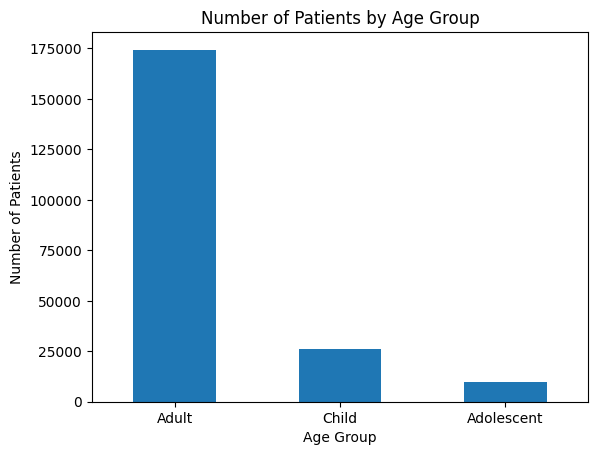

In [11]:
import matplotlib.pyplot as plt
# Visualize the number of patients in each age group
age_counts = df["AgeGroup"].value_counts()
age_counts.plot(kind="bar")
plt.title("Number of Patients by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Number of Patients")
plt.xticks(rotation=0)
plt.show()

#observation
Most of the records are from adults followed by children while adolescennts have the fewest records.

In [12]:
#check the number of patients by gender
gender_counts=df["Gender"].value_counts()
gender_counts

,count
Gender,
Female,97347
Male,74871
FEMALE,23826
MALE,14008


In [13]:
#Standardize gender
# Standardize gender labels
df["Gender"] = df["Gender"].str.upper().str.strip()
# Check the result
df["Gender"].value_counts()


,count
Gender,
FEMALE,121173
MALE,88879


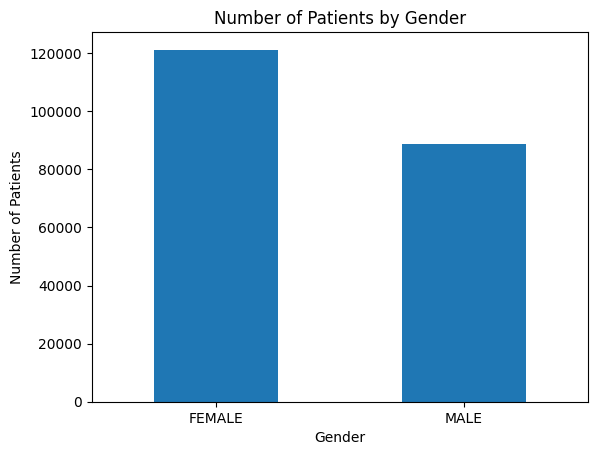

In [14]:
#visualize patients by gender
gender_counts = df["Gender"].value_counts()

gender_counts.plot(kind="bar")

plt.title("Number of Patients by Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Patients")
plt.xticks(rotation=0)
plt.show()

create the return visit feature.


In [15]:
# Create a return visit feature
df["ReturnVisit"] = df["PatientNumber"].duplicated(keep="first")

# Check the result
df["ReturnVisit"].value_counts()

,count
ReturnVisit,
True,147685
False,62367


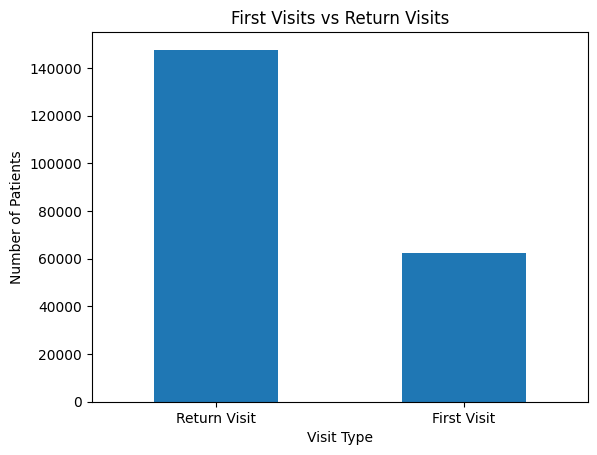

In [16]:
# Visualize first visits and return visits
return_counts = df["ReturnVisit"].value_counts()
return_counts.index = ["Return Visit" if x else "First Visit" for x in return_counts.index]

return_counts.plot(kind="bar")

plt.title("First Visits vs Return Visits")
plt.xlabel("Visit Type")
plt.ylabel("Number of Patients")
plt.xticks(rotation=0)
plt.show()

#observation
most of the records are return visits while fewer records are first visits

In [17]:
#RETURN BEHAVIOR BY AGE GROUP
# Check return visits across age groups
age_return = pd.crosstab(df["AgeGroup"], df["ReturnVisit"])

age_return

ReturnVisit,False,True
AgeGroup,,
Adolescent,3571,5970
Adult,49081,125298
Child,9715,16417


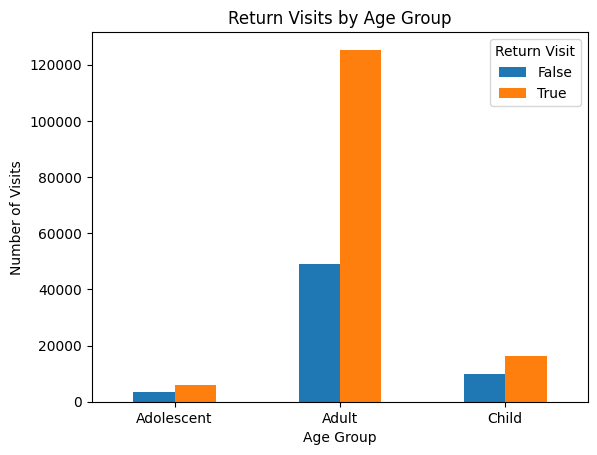

In [18]:
# Visualize return visits by age group
age_return.plot(kind="bar")

plt.title("Return Visits by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Number of Visits")
plt.xticks(rotation=0)
plt.legend(title="Return Visit")
plt.show()

Observation

adults have the highest number of both first and return visits..in all the age groups return visits are higher than the first visit.

In [19]:
# Check return visits across gender
gender_return = pd.crosstab(df["Gender"], df["ReturnVisit"])

gender_return

ReturnVisit,False,True
Gender,,
FEMALE,35502,85671
MALE,26865,62014


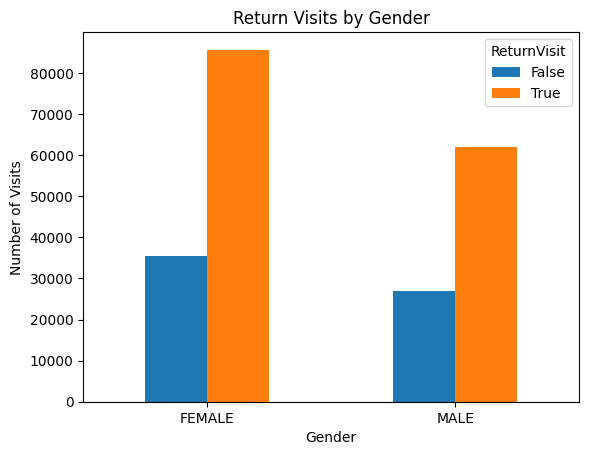

In [20]:
# Visualize return visits by gender
gender_return.plot(kind="bar")

plt.title("Return Visits by Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Visits")
plt.xticks(rotation=0)
plt.show()

observations


female patients have more return visits than mal patients



In [21]:
# Calculate return rate for each age group
age_return_rate = pd.crosstab(
    df["AgeGroup"],
    df["ReturnVisit"],
    normalize="index"
) * 100

age_return_rate

ReturnVisit,False,True
AgeGroup,,
Adolescent,37.427943,62.572057
Adult,28.146164,71.853836
Child,37.176642,62.823358


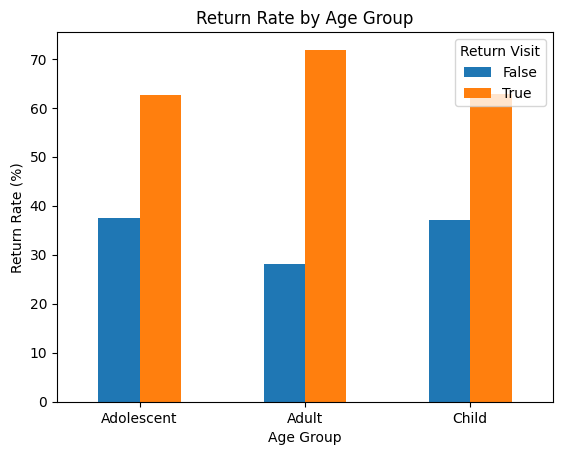

In [22]:
# Visualize return rates by age group
age_return_rate.plot(kind="bar")

plt.title("Return Rate by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Return Rate (%)")
plt.xticks(rotation=0)
plt.legend(title="Return Visit")
plt.show()

Observation

Adults have the highest return rate at about 74% while children and adolescents have similar return rates of about 65%.



In [23]:
# Check return visits by consultation type
consult_return = pd.crosstab(
    df["ConsultDescription"],
    df["ReturnVisit"]
)

consult_return

ReturnVisit,False,True
ConsultDescription,,
ANC First Visit,2,2
ANC Revisit,4,12
Admis,0,1
Admission,3964,14150
Adult Neurology,14,42
...,...,...
Staff Wellness Package,0,1
Surgical OPD,0,1
TB CLINIC,0,7


In [24]:
# Find the consultation types with the most return visits
top_return = consult_return.sort_values(by=True, ascending=False).head(10)

top_return

ReturnVisit,False,True
ConsultDescription,,
General Outpatient Care,9195,26930
Admission,3964,14150
CONSULT,10750,13943
MCH Clinic,2657,11639
RENAL DIALYSIS,51,8060
Chemotherapy,291,7669
ORTHOPEDIC,1213,6944
Comprehensive Care Centre (CCC),1343,5592
Pediatrics,1301,4979


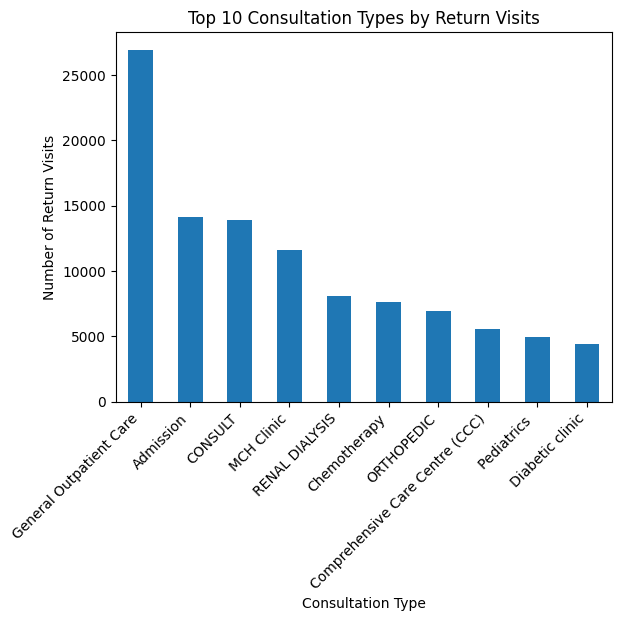

In [25]:
# Visualize the top 10 consultation types by return visits
top_return[True].plot(kind="bar")

plt.title("Top 10 Consultation Types by Return Visits")
plt.xlabel("Consultation Type")
plt.ylabel("Number of Return Visits")
plt.xticks(rotation=45, ha="right")
plt.show()

Observation

General Outpatient Care has the highest number of return visits, followed by Admission and CONSULT. This suggests that patients receiving these services are more likely to return for further care.

In [26]:
# Calculate return rate by gender
gender_return_rate = pd.crosstab(
    df["Gender"],
    df["ReturnVisit"],
    normalize="index"
) * 100

gender_return_rate

ReturnVisit,False,True
Gender,,
FEMALE,29.298606,70.701394
MALE,30.226488,69.773512


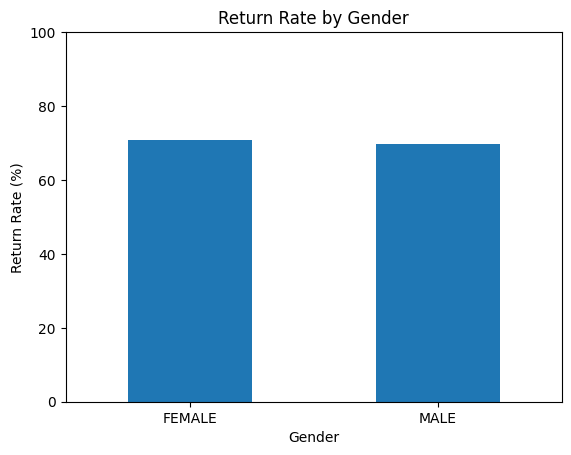

In [27]:
# Visualize return rates by gender
gender_return_rate[True].plot(kind="bar")

plt.title("Return Rate by Gender")
plt.xlabel("Gender")
plt.ylabel("Return Rate (%)")
plt.xticks(rotation=0)
plt.ylim(0, 100)
plt.show()

Observation

Female patients have a slightly higher return rate than male patients, but the difference is small. This suggests that gender may not have a strong effect on whether patients return.

In [30]:
# Calculate the total number of patients for each consultation type
consult_total = df["ConsultDescription"].value_counts()

# Keep consultation types with at least 100 patients
common_consults = consult_total[consult_total >= 100].index

# Calculate return rate for each consultation type
consult_return_rate = pd.crosstab(
    df["ConsultDescription"],
    df["ReturnVisit"],
    normalize="index"
) * 100

# Calculate return rate for the more common consultation types
consult_return_rate_filtered = consult_return_rate.loc[common_consults]

# Show the 10 consultation types with the highest return rates
consult_return_rate_filtered.sort_values(
    by=True, ascending=False)

ReturnVisit,False,True
ConsultDescription,,
RENAL DIALYSIS,0.628776,99.371224
Program Patients,0.715137,99.284863
Chemotherapy,3.655779,96.344221
SPECIALITY IMED,3.827751,96.172249
Physiotherapy,4.421594,95.578406
Gen Surg OPD,5.882353,94.117647
Psychiatry,6.282723,93.717277
Revisit,7.850467,92.149533
DAYCASE,8.982036,91.017964


In [31]:
# Remove consultation types that explicitly describe a return/revisit
consult_return_rate_clean = consult_return_rate_filtered[
    ~consult_return_rate_filtered.index.str.contains(
        "return|revisit", case=False, na=False
    )
]

# Get the 10 consultation types with the highest return rates
top_return_rate = consult_return_rate_clean.sort_values(
    by=True, ascending=False
).head(10)

top_return_rate

ReturnVisit,False,True
ConsultDescription,,
RENAL DIALYSIS,0.628776,99.371224
Program Patients,0.715137,99.284863
Chemotherapy,3.655779,96.344221
SPECIALITY IMED,3.827751,96.172249
Physiotherapy,4.421594,95.578406
Gen Surg OPD,5.882353,94.117647
Psychiatry,6.282723,93.717277
DAYCASE,8.982036,91.017964
ONCOLOGY CONSULTATION,9.341564,90.658436


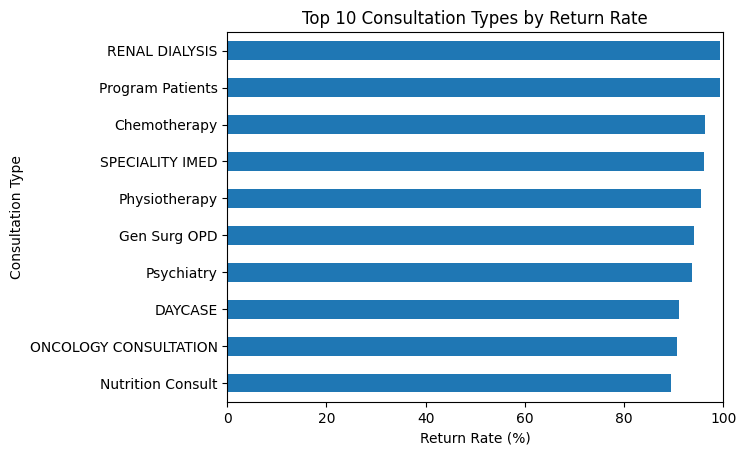

In [32]:
# Visualize the top 10 consultation types by return rate

top_return_rate[True].sort_values().plot(kind="barh")

plt.title("Top 10 Consultation Types by Return Rate")
plt.xlabel("Return Rate (%)")
plt.ylabel("Consultation Type")
plt.xlim(0, 100)
plt.show()

Observation

Renal Dialysis has the highest return rate at about 99.5%, followed by Program Patients at about 99.2%. The other consultation types also have high return rates, all above 92%. This shows that patients receiving these services are highly likely to return for further care.

#OVERAL CONCLUSION

The analysis shows that most patients return for further care. Adults have the highest return rate among the age groups while female and male patients have very similar return rates...Some consultation types especially Renal Dialysis and Program Patients, have very high return rates..Overall the results suggest that patient age and consultation type may influence return behavior while gender appears to have a smaller difference.

#HYPOTHESIS
Null Hypothesis (H₀): There is no significant relationship between patient characteristics and whether a patient returns for another visit.

Alternative Hypothesis (H₁): There is a significant relationship between patient characteristics and whether a patient returns for another visit.

# Feature Engineering for Demand Forecasting

Everything so far has been patient-level (one row per visit). To predict congestion,
we need department-hour level data instead: "how many patients showed up in this
department, in this hour." This section builds that, following the approach used
in the OPD Congestion — Model Selection & Feature Engineering reference notebook.

In [ ]:
# Group the ~79 raw consultation labels into 7 broader categories
df["ConsultClean"] = (
    df["ConsultDescription"]
    .fillna("UNKNOWN")
    .str.strip()
    .str.upper()
    .str.replace(r"\.$", "", regex=True)
    .str.replace(r"\s+", " ", regex=True)
)

service_map = {}
for label in ["GENERAL OUTPATIENT CARE", "CONSULT", "GENERAL OUTPATIENT CARE( NEW )",
              "REVISIT", "UNKNOWN", "CONSULTANT CLINIC"]:
    service_map[label] = "Admin / Unspecified"
for label in ["ADMISSION", "DAYCASE", "EMERGENCY"]:
    service_map[label] = "Inpatient / Emergency"
for label in ["RENAL DIALYSIS", "CHEMOTHERAPY", "PHYSIOTHERAPY",
              "HEPATITIS B VACCINE", "OCCUPATIONAL THERAPY"]:
    service_map[label] = "Procedure / Treatment"
for label in ["TELEMEDICINE", "STAFF CLINIC", "STAFF WELLNESS PACKAGE",
              "GENERAL WELLNESS PACKAGE", "PROGRAM PATIENTS", "RVA"]:
    service_map[label] = "Non-Physical / Special Cohort"
for label in ["ECHO", "CANCER SCREENING", "CSSR CANCER SCREENING", "EAR SCREENING"]:
    service_map[label] = "Diagnostic / Screening"
for label in ["MCH CLINIC", "MCH (NEW PATIENT)", "CHILD WELFARE AND IMMUNIZATION (CWC)",
              "DEVELOPMENTAL CLINIC", "FAMILY PLANNING", "ANC REVISIT",
              "ANC FIRST VISIT", "POSTNATAL (PNC)"]:
    service_map[label] = "Maternal & Child Health"

specialty = [
    "ORTHOPEDIC", "COMPREHENSIVE CARE CENTRE (CCC)", "PEDIATRICS", "DENTAL CARE",
    "DIABETIC CLINIC", "GENERAL SURGERY", "GEN SURG OPD", "SURGICAL OPD",
    "ENT RETURN VISIT", "ENT FIRST VISIT", "UROLOGY", "GYNAECOLOGY", "GYNE ONCOLOGY",
    "GYN-ONCOLOGY", "PRIVATE GYN ONCOLOGY", "CARDIOLOGY", "OPHTHALMOLOGY", "EYE CLINIC",
    "ONCOLOGY CONSULTATION", "ONCOLOGY SERVICE", "PLASTICS", "BREAST",
    "NEUROSURGERY OUTPATIENT CLINIC", "ADULT NEUROLOGY", "PAEDS NEUROLOGY",
    "PSYCHIATRY", "PAEDIATRIC PSYCHIATRY", "COUNSELLING PSYCHOLOGY",
    "CLINICAL PSYCHOLOGY CONSULTATION", "COUNSELLING", "NUTRITION CONSULT",
    "SPINE CLINIC", "LIMB RECONSTRUCTION CONSULTATION", "RENAL CLINIC",
    "RENAL CONSULTATION", "NEPHROLOGY CLINIC", "DERMATOLOGY CONSULTATION",
    "ANAESTHESIA CONSULT", "PALLIATIVE REVISIT", "LUNG CLINIC", "HAND CLINIC",
    "TB CLINIC", "HYPERTENSION CLINIC", "PAIN CLINIC", "HEAD AND NECK VISIT",
    "HEAD & NECK RETURN VISIT", "PEADS SURGE", "SPECIALITY IMED",
]
for label in specialty:
    service_map[label] = "Specialty Clinic"

df["ServiceGroup"] = df["ConsultClean"].map(service_map).fillna("Other / Unmapped")
df["ServiceGroup"].value_counts()

**Observation**

All consult labels matched the mapping - 0 fell into "Other / Unmapped". Admin/Unspecified
(105,234) and Specialty Clinic (86,911) are the two largest groups, followed by
Inpatient/Emergency, Maternal & Child Health, Procedure/Treatment, Non-Physical/Special
Cohort, and a small Diagnostic/Screening group (566).

### Lab-need features

Each Specialty Clinic label is assigned a likelihood of sending the patient to the lab
(`Always/Often/Rarely/Never`), plus a typical turnaround time. This matters for congestion
because a patient waiting on same-day lab results occupies space in the building longer
than one who doesn't.

In [ ]:
lab_always = ["DIABETIC CLINIC", "COMPREHENSIVE CARE CENTRE (CCC)", "RENAL CLINIC",
    "RENAL CONSULTATION", "NEPHROLOGY CLINIC", "TB CLINIC", "HYPERTENSION CLINIC",
    "ONCOLOGY CONSULTATION", "ONCOLOGY SERVICE", "GYNE ONCOLOGY", "GYN-ONCOLOGY",
    "PRIVATE GYN ONCOLOGY", "BREAST"]
lab_often = ["GENERAL SURGERY", "GEN SURG OPD", "SURGICAL OPD", "ANAESTHESIA CONSULT",
    "CARDIOLOGY", "UROLOGY", "GYNAECOLOGY", "PEDIATRICS", "PEADS SURGE",
    "ADULT NEUROLOGY", "PAEDS NEUROLOGY", "NEUROSURGERY OUTPATIENT CLINIC",
    "LUNG CLINIC", "SPECIALITY IMED", "PALLIATIVE REVISIT"]
lab_rarely = ["ORTHOPEDIC", "SPINE CLINIC", "LIMB RECONSTRUCTION CONSULTATION",
    "HAND CLINIC", "PLASTICS", "DERMATOLOGY CONSULTATION", "OPHTHALMOLOGY",
    "EYE CLINIC", "ENT FIRST VISIT", "ENT RETURN VISIT", "HEAD AND NECK VISIT",
    "HEAD & NECK RETURN VISIT", "PAIN CLINIC", "NUTRITION CONSULT"]
lab_never = ["DENTAL CARE", "PSYCHIATRY", "PAEDIATRIC PSYCHIATRY",
    "COUNSELLING PSYCHOLOGY", "CLINICAL PSYCHOLOGY CONSULTATION", "COUNSELLING"]

lab_map = {}
for x in lab_always: lab_map[x] = "Always"
for x in lab_often:  lab_map[x] = "Often"
for x in lab_rarely: lab_map[x] = "Rarely"
for x in lab_never:  lab_map[x] = "Never"

df["LabNeed"] = df["ConsultClean"].map(lab_map).fillna("Never")
lab_minutes = {"Always": 120, "Often": 120, "Rarely": 90, "Never": 0}
df["LabTatMins"] = df["LabNeed"].map(lab_minutes)
df["LabSameDay"] = df["LabNeed"].isin(["Always", "Often", "Rarely"])

df["LabNeed"].value_counts()

**Observation**

Never: 210,753, Often: 29,591, Rarely: 27,069, Always: 20,857 - about 27% of visits
(`LabSameDay`) are estimated to involve a same-day lab step. Note the assumption: anything
not explicitly in the mapping (including "Other / Unmapped" service types) defaults to
"Never" rather than being treated as unknown.

### Calendar features

- `hour` - hour of day (0-23), since OPD traffic isn't evenly spread through the day.
- `day_of_week` - Monday=0 ... Sunday=6, since MCH clinics run on fixed weekdays.
- `is_weekend` - weekends likely behave differently.
- `month` - to capture any seasonal dip/spike.

In [ ]:
df["date"] = df["RegistrationDate"].dt.date
df["hour"] = df["RegistrationDate"].dt.hour
df["day_of_week"] = df["RegistrationDate"].dt.dayofweek   # Monday=0 ... Sunday=6
df["is_weekend"] = df["day_of_week"] >= 5
df["month"] = df["RegistrationDate"].dt.month

df[["date", "hour", "day_of_week", "is_weekend", "month"]].sample(5)

**Observation**

Data spans 1 June 2024 to 19 August 2026, with all 12 months represented - a good spread
for catching seasonal patterns. `AgeGroup` from earlier in the notebook is left as-is; no
need to rebuild it here.

## Build the modeling table: hourly arrivals per department

This is the key step. So far every row is one visit - there's no "congestion" number yet.
Grouping by date, hour, and department turns each visit into a count: "this many patients
showed up in this department, in this hour." That count becomes what the model predicts.

In [ ]:
# Drop rows with an unparseable timestamp - can't place them in a specific hour
ts_df = df.dropna(subset=["RegistrationDate"]).copy()

hourly = (
    ts_df.groupby(["date", "hour", "QueuedTo"])
    .size()
    .reset_index(name="visit_count")
)

hourly["date"] = pd.to_datetime(hourly["date"])
hourly["day_of_week"] = hourly["date"].dt.dayofweek
hourly["is_weekend"] = hourly["day_of_week"] >= 5
hourly["month"] = hourly["date"].dt.month

hourly.head()

**Observation**

82,089 department-hour rows across 41 departments. Typical hour has 1-4 visits (median 2),
busiest single hour hit 59 visits in one department.

### Bonus feature: return-visit share per hour

This notebook already built a `ReturnVisit` flag at the patient level - the reference
notebook doesn't have this. Folding it into the hourly table adds a feature unique to this
project: what share of each hour's patients were returning patients.

In [ ]:
return_share = (
    ts_df.groupby(["date", "hour", "QueuedTo"])["ReturnVisit"]
    .mean()
    .reset_index(name="return_visit_share")
)
return_share["date"] = pd.to_datetime(return_share["date"])

hourly = hourly.merge(return_share, on=["date", "hour", "QueuedTo"], how="left")
hourly.head()

**Observation**

Averages 0.72 across all department-hours. For the Renal department specifically it's
0.996 - almost exactly matching the ~99.5% return rate found in the earlier EDA, which is
a good sign this feature captures something real.

### Lag features

The strongest signal for "how busy is a department right now" is usually "how busy was it
a moment ago." Both features below are shifted so the model never sees the value it's
trying to predict.

In [ ]:
hourly = hourly.sort_values(["QueuedTo", "date", "hour"]).reset_index(drop=True)

hourly["lag_1h"] = hourly.groupby("QueuedTo")["visit_count"].shift(1)
hourly["rolling_3h_avg"] = (
    hourly.groupby("QueuedTo")["visit_count"]
    .transform(lambda s: s.shift(1).rolling(3).mean())
)

# the first couple of hours per department have no history yet - drop them
model_df = hourly.dropna(subset=["lag_1h", "rolling_3h_avg"]).copy()
model_df.head()

**Observation**

Only 121 rows (0.15%) dropped for missing lag history - about 3 rows per department,
right in the expected range.

## Quick sanity-check model

This isn't the final tuned model - it's a fast check that the features above actually
carry useful signal.

Two things matter here:
- **The split is by date, not random.** Shuffling would let the model "see the future"
  through lag features, which would make the score look better than it really is.
- `QueuedTo` (department) is turned into numeric codes since Random Forest needs numbers,
  not text.

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error

model_df["QueuedTo_code"] = model_df["QueuedTo"].astype("category").cat.codes

cutoff = model_df["date"].quantile(0.8)   # last ~20% of dates held out as a test set
train = model_df[model_df["date"] < cutoff]
test = model_df[model_df["date"] >= cutoff]

features = ["hour", "day_of_week", "is_weekend", "month",
            "QueuedTo_code", "lag_1h", "rolling_3h_avg", "return_visit_share"]
X_train, y_train = train[features], train["visit_count"]
X_test, y_test = test[features], test["visit_count"]

model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print("MAE:", mean_absolute_error(y_test, y_pred))

**Observation**

MAE is about 1.17 patients per hour on held-out (future) dates.

## What's actually driving predictions?

Feature importance shows which inputs the model relies on most - useful for checking the
features make sense, and for telling the hospital what drives congestion.

In [ ]:
importances = pd.Series(model.feature_importances_, index=features).sort_values(ascending=False)
sns.barplot(x=importances.values, y=importances.index)
plt.title("Feature Importance - Hourly Visit Count Model")
plt.xlabel("Importance")
plt.show()

**Observation**

`lag_1h` drives the model most (about 43% importance), with `return_visit_share` a strong
second (about 20%) - ahead of hour, department, and the rolling average. The return-visit
feature already built earlier in this notebook turned out to be genuinely useful for
predicting congestion, not just a side analysis.